In [19]:
import os
os.chdir("/Users/srujansingh/Documents/JeanFan_Lab/Kidney_Structural_Analysis/")

In [20]:
import scanpy as sc
#ctrl1_data only contains the all the tubule annotations:
ctrl1_data = sc.read_h5ad("data/2um/Ctrl_1A2/Ctrl_1A2_visiumhd_2um_proximal_labeled.h5ad")
ctrl1_data.obs.shape

(5549563, 6)

In [39]:
ctrl1_data.obs

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,proximal_tubule_geojson_feature_index
s_002um_00000_02609-1,1,0,2609,1164.609932,6249.759373,<NA>
s_002um_00000_02610-1,1,0,2610,1164.662587,6245.220638,<NA>
s_002um_00000_02611-1,1,0,2611,1164.715242,6240.681902,<NA>
s_002um_00000_02612-1,1,0,2612,1164.767897,6236.143167,<NA>
s_002um_00000_02613-1,1,0,2613,1164.820552,6231.604433,<NA>
...,...,...,...,...,...,...
s_002um_03347_00386-1,1,3347,386,16228.588784,16511.566120,<NA>
s_002um_03347_00387-1,1,3347,387,16228.641352,16507.027106,<NA>
s_002um_03347_00388-1,1,3347,388,16228.693919,16502.488091,<NA>
s_002um_03347_00389-1,1,3347,389,16228.746486,16497.949076,<NA>


In [40]:
#Subset the AnnData to only contain proximal tubules
ctrl1_A2_PT=ctrl1_data[~ctrl1_data.obs['proximal_tubule_geojson_feature_index'].isna()]
ctrl1_A2_PT.shape #to check the dimensions of the subset matrix.
ctrl1_A2_PT.obs

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,proximal_tubule_geojson_feature_index
s_002um_00304_00021-1,1,304,21,2407.153091,18011.820723,929
s_002um_00304_00022-1,1,304,22,2407.205739,18007.281833,929
s_002um_00304_00023-1,1,304,23,2407.258388,18002.742943,929
s_002um_00304_00024-1,1,304,24,2407.311036,17998.204053,929
s_002um_00304_00025-1,1,304,25,2407.363684,17993.665163,929
...,...,...,...,...,...,...
s_002um_03081_00927-1,1,3081,927,15050.493122,14042.298862,5938
s_002um_03081_00928-1,1,3081,928,15050.545696,14037.759889,5938
s_002um_03081_00929-1,1,3081,929,15050.598270,14033.220917,5938
s_002um_03081_00930-1,1,3081,930,15050.650844,14028.681944,5938


In [4]:
select_genes = ["Slc34a1", "Slc5a2","Slc9a3","Aqp1","Vil1","Dpp4", "Atp1a1","Atp1b1","Slc4a4","Slc2a1","Slc7a7"]
[g in ctrl1_data.var_names for g in select_genes]

[True, True, True, True, True, True, True, True, True, True, True]

1.BRUSH BORDER (APICAL MARKERS)

A.Transporters / channels<br>

Slc34a1 – sodium-phosphate cotransporter (classic proximal tubule marker) <br>
Slc5a2 – SGLT2 (glucose reabsorption, very apical)<br>
Slc9a3 – NHE3 (Na⁺/H⁺ exchanger, strongly apical)<br>
Aqp1 – aquaporin-1 (proximal tubule water transport, apical + membrane-wide)<br>

B.Brush border structural / membrane proteins<br>

Vil1 – villin (microvilli actin bundling; strong brush border marker)<br>
Dpp4 – dipeptidyl peptidase 4 (apical membrane enzyme)<br>

2.BASOLATERAL PROXIMAL TUBULE MARKERS:
A.Ion transport / pumps<br>

Atp1a1 – Na⁺/K⁺ ATPase α1 (canonical basolateral pump)<br>
Atp1b1 – Na⁺/K⁺ ATPase β1 subunit<br>
Slc4a4 – NBCe1 (bicarbonate transporter, basolateral acid-base handling)<br>

B.Metabolite / ion exchange<br>

Slc2a1 – GLUT1 (often basolateral glucose transport in certain PT segments)<br>
Slc7a7 – amino acid transport (basolateral exchange roles)

In [22]:
#ctrl1_A2_PTselect=ctrl1_A2_PT[:,select_genes]
ctrl1_A2_PTselect.shape

(881056, 11)

In [23]:
ctrl1_A2_PTselect.to_df()

,Slc34a1,Slc5a2,Slc9a3,Aqp1,Vil1,Dpp4,Atp1a1,Atp1b1,Slc4a4,Slc2a1,Slc7a7
s_002um_00304_00021-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_002um_00304_00022-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_002um_00304_00023-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_002um_00304_00024-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_002um_00304_00025-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
s_002um_03081_00927-1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
s_002um_03081_00928-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_002um_03081_00929-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_002um_03081_00930-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
ctrl1_A2_PTselect.obs

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,proximal_tubule_geojson_feature_index
s_002um_00304_00021-1,1,304,21,2407.153091,18011.820723,929
s_002um_00304_00022-1,1,304,22,2407.205739,18007.281833,929
s_002um_00304_00023-1,1,304,23,2407.258388,18002.742943,929
s_002um_00304_00024-1,1,304,24,2407.311036,17998.204053,929
s_002um_00304_00025-1,1,304,25,2407.363684,17993.665163,929
...,...,...,...,...,...,...
s_002um_03081_00927-1,1,3081,927,15050.493122,14042.298862,5938
s_002um_03081_00928-1,1,3081,928,15050.545696,14037.759889,5938
s_002um_03081_00929-1,1,3081,929,15050.598270,14033.220917,5938
s_002um_03081_00930-1,1,3081,930,15050.650844,14028.681944,5938


CONVERT THE BINS IN A PROXIMAL TUBULE TO A DISTANCE MAP (FOR A SINGLE MAP)

In [25]:
#Importing the geojson files which contains the proximal tubule annotations and boudary information.
import geopandas as gpd
gdf=gpd.read_file("data/2um/geojson/Ctrl_1A2_tubules_processed_caleb.geojson")

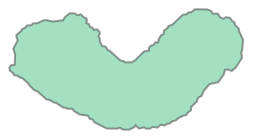

In [26]:
#Extracting geometrical information for a particular PT (let's ID=929 on the geojson file)
tubule=gdf[gdf["id"]=="929"]
geom=tubule.geometry.iloc[0]
geom

In [30]:
subset = ctrl1_A2_PT[ctrl1_A2_PT.obs['proximal_tubule_geojson_feature_index'].astype(str) == "929"].copy()


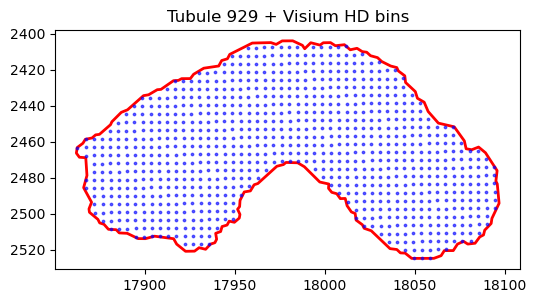

In [27]:
#Extract corresponding bin coordinates:
subset = ctrl1_A2_PTselect[ctrl1_A2_PTselect.obs['proximal_tubule_geojson_feature_index'].astype(str) == "929"].copy()

x = subset.obs["pxl_col_in_fullres"]
y = subset.obs["pxl_row_in_fullres"]

#Overlay/Plot together:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,6))

# 1. plot tubule polygon
gdf[gdf["id"] == "929"].plot(ax=ax, color="none", edgecolor="red", linewidth=2)

# 2. plot bins inside tubule
ax.scatter(x, y, s=3, c="blue", alpha=0.6)

ax.set_aspect("equal")
ax.invert_yaxis()  # IMPORTANT for image coordinate systems
ax.set_title("Tubule 929 + Visium HD bins")

plt.show()

In [11]:
#Convert bins to shapely points:
from shapely.geometry import Point
points = [Point(xy) for xy in zip(x, y)]

In [12]:
#Extract the polygon boundary:
boundary = geom.boundary

In [13]:
#Computing distance to edge:
distances = [p.distance(boundary) for p in points]

In [14]:
#Append this new distance matrix into the subset data:
subset.obs["dist_to_edge"] = distances

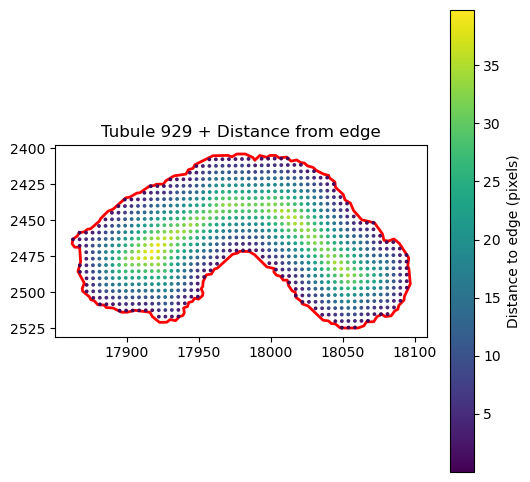

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))

# plotting the polygon (from the geojson file)
gdf[gdf["id"] == "929"].plot(ax=ax, color="none", edgecolor="red", linewidth=2)

# plot the Visium HD bins scatter 
sc = ax.scatter(
    subset.obs["pxl_col_in_fullres"].values,
    subset.obs["pxl_row_in_fullres"].values,
    c=subset.obs["dist_to_edge"].values,
    s=3,
    cmap="viridis"
)

# attach colorbar to SAME figure
fig.colorbar(sc, ax=ax, label="Distance to edge (pixels)")

ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_title("Tubule 929 + Distance from edge")

plt.show()

NOW, WE SEGREGATE THE BINS BASED ON THEIR DISTANCE FROM THE EDGE:<br>
1. BASAL SIDE BINS - BINS WITH DISTANCE BETWEEN 0-10.
1. APICAL SIDE BINS - BINS WITH DISTANCE BETWEEN >10-20.

Text(0.5, 1.0, 'Tubule 929 with all basal bins')

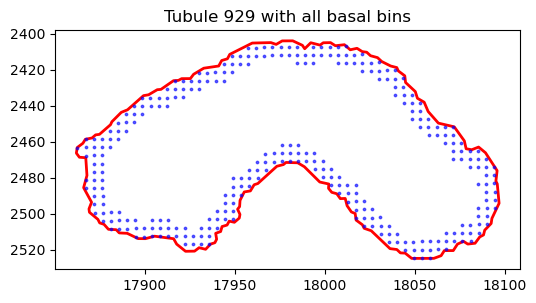

In [ ]:
#PLOTTING THE BASAL BINS:
fig, ax = plt.subplots(figsize=(6,6))

# plotting the polygon (from the geojson file)
gdf[gdf["id"] == "929"].plot(ax=ax, color="none", edgecolor="red", linewidth=2)

basal=subset[subset.obs["dist_to_edge"].values<=10].copy()

# plot the Visium HD bins scatter 
sc = ax.scatter(
    basal.obs["pxl_col_in_fullres"].values,
    basal.obs["pxl_row_in_fullres"].values,
    c="blue",
    s=3,
    alpha=0.6
)

ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_title("Tubule 929 with all basal bins")



Text(0.5, 1.0, 'Tubule 929 with all apical bins')

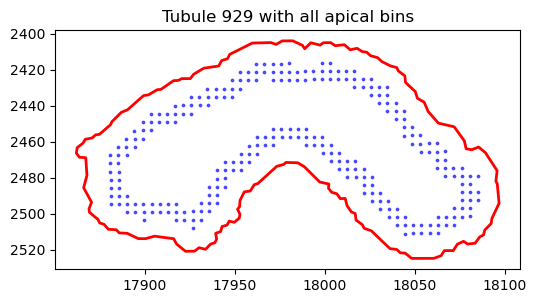

In [64]:
#PLOTTING THE APICAL BINS:
fig, ax = plt.subplots(figsize=(6,6))

# plotting the polygon (from the geojson file)
gdf[gdf["id"] == "929"].plot(ax=ax, color="none", edgecolor="red", linewidth=2)

apical=subset[(subset.obs["dist_to_edge"].values>10)&(subset.obs["dist_to_edge"].values<=20)].copy()

# plot the Visium HD bins scatter 
sc = ax.scatter(
    apical.obs["pxl_col_in_fullres"].values,
    apical.obs["pxl_row_in_fullres"].values,
    c="blue",
    s=3,
    alpha=0.6
)

ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_title("Tubule 929 with all apical bins")

Text(0.5, 1.0, 'Tubule 929 with all apical bins')

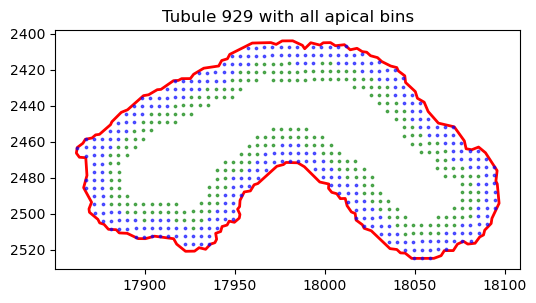

In [ ]:
#PLOTTING THE BASAL AND APICAL BINS TOGETHER:
fig, ax = plt.subplots(figsize=(6,6))

# plotting the polygon (from the geojson file)
gdf[gdf["id"] == "929"].plot(ax=ax, color="none", edgecolor="red", linewidth=2)

basal=subset[subset.obs["dist_to_edge"].values<=10].copy()
apical=subset[(subset.obs["dist_to_edge"].values>10)&(subset.obs["dist_to_edge"].values<=20)].copy()

# plot the Visium HD bins scatter 
sc = ax.scatter(
    basal.obs["pxl_col_in_fullres"].values,
    basal.obs["pxl_row_in_fullres"].values,
    c="blue",
    s=3,
    alpha=0.6
)
sc = ax.scatter(
    apical.obs["pxl_col_in_fullres"].values,
    apical.obs["pxl_row_in_fullres"].values,
    c="green",
    s=3,
    alpha=0.6
)

ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_title("Tubule 929 with all apical and basal bins")

In [ ]:
gene = "Slc34a1"
expr_all=subset[:, gene].X.toarray()
expr_apical = apical[:, gene].X.toarray()
expr_basal  = basal[:, gene].X.toarray()


APICAL MARKERS VV

Text(0.5, 1.0, 'Tubule 929 (Vil1 Expression)')

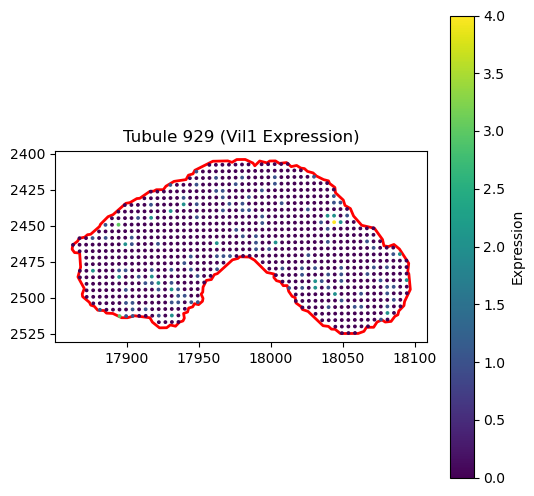

In [34]:
#VISUALIZE GENE EXPRESSION:
expr_all=subset[:, "Slc34a1"].X.toarray()


fig, ax = plt.subplots(figsize=(6,6))

# plotting the polygon (from the geojson file)
gdf[gdf["id"] == "929"].plot(ax=ax, color="none", edgecolor="red", linewidth=2)

# plot the Visium HD bins scatter 
sc = ax.scatter(
    subset.obs["pxl_col_in_fullres"].values,
    subset.obs["pxl_row_in_fullres"].values,
    c=expr_all,
    s=3,
    alpha=1
)

# attach colorbar to SAME figure
fig.colorbar(sc, ax=ax, label="Expression")

ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_title("Tubule 929 (Vil1 Expression)")

Text(0.5, 1.0, 'Tubule 929 (Slc5a2 Expression)')

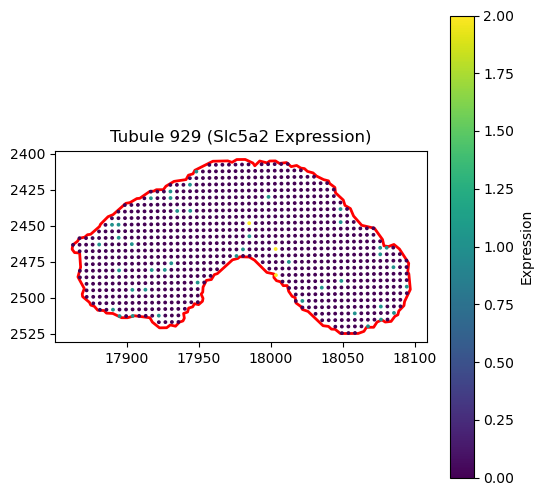

In [101]:
#VISUALIZE GENE EXPRESSION:
expr_all=subset[:, "Slc5a2"].X.toarray()


fig, ax = plt.subplots(figsize=(6,6))

# plotting the polygon (from the geojson file)
gdf[gdf["id"] == "929"].plot(ax=ax, color="none", edgecolor="red", linewidth=2)

# plot the Visium HD bins scatter 
sc = ax.scatter(
    subset.obs["pxl_col_in_fullres"].values,
    subset.obs["pxl_row_in_fullres"].values,
    c=expr_all,
    s=3,
    alpha=1
)

# attach colorbar to SAME figure
fig.colorbar(sc, ax=ax, label="Expression")

ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_title("Tubule 929 (Slc5a2 Expression)")

Text(0.5, 1.0, 'Tubule 929 (Slc9a3 Expression)')

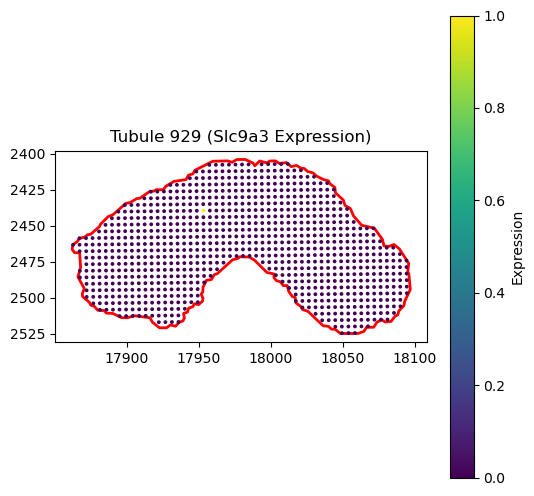

In [102]:
#VISUALIZE GENE EXPRESSION:
expr_all=subset[:, "Slc9a3"].X.toarray()


fig, ax = plt.subplots(figsize=(6,6))

# plotting the polygon (from the geojson file)
gdf[gdf["id"] == "929"].plot(ax=ax, color="none", edgecolor="red", linewidth=2)

# plot the Visium HD bins scatter 
sc = ax.scatter(
    subset.obs["pxl_col_in_fullres"].values,
    subset.obs["pxl_row_in_fullres"].values,
    c=expr_all,
    s=3,
    alpha=1
)

# attach colorbar to SAME figure
fig.colorbar(sc, ax=ax, label="Expression")

ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_title("Tubule 929 (Slc9a3 Expression)")

BASAL MARKERS EXPRESSION VV

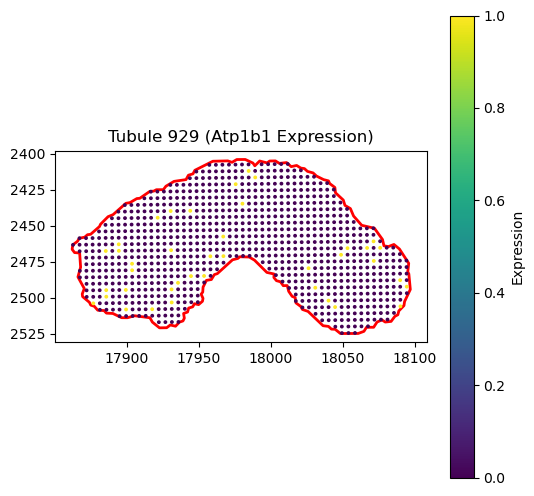

In [98]:
#VISUALIZE GENE EXPRESSION:
expr_all=subset[:, "Atp1b1"].X.toarray()


fig, ax = plt.subplots(figsize=(6,6))

# plotting the polygon (from the geojson file)
gdf[gdf["id"] == "929"].plot(ax=ax, color="none", edgecolor="red", linewidth=2)

# plot the Visium HD bins scatter 
sc = ax.scatter(
    subset.obs["pxl_col_in_fullres"].values,
    subset.obs["pxl_row_in_fullres"].values,
    c=expr_all,
    s=3,
    alpha=1
)

# attach colorbar to SAME figure
fig.colorbar(sc, ax=ax, label="Expression")

ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_title("Tubule 929 (Atp1b1 Expression)")

plt.show()

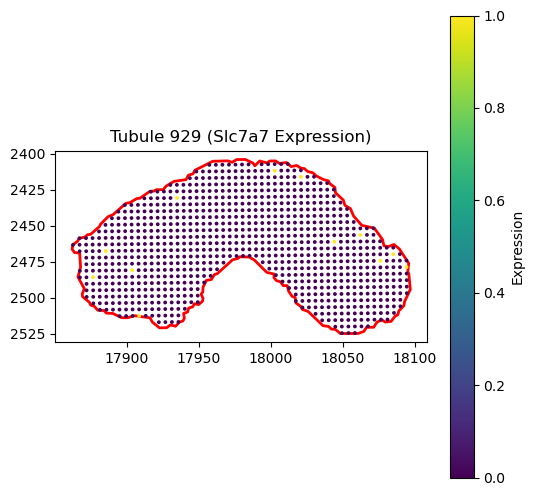

In [100]:
#VISUALIZE GENE EXPRESSION:
expr_all=subset[:, "Slc7a7"].X.toarray()


fig, ax = plt.subplots(figsize=(6,6))

# plotting the polygon (from the geojson file)
gdf[gdf["id"] == "929"].plot(ax=ax, color="none", edgecolor="red", linewidth=2)

# plot the Visium HD bins scatter 
sc = ax.scatter(
    subset.obs["pxl_col_in_fullres"].values,
    subset.obs["pxl_row_in_fullres"].values,
    c=expr_all,
    s=3,
    alpha=1
)

# attach colorbar to SAME figure
fig.colorbar(sc, ax=ax, label="Expression")

ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_title("Tubule 929 (Slc7a7 Expression)")

plt.show()

Text(0.5, 1.0, 'Tubule 929 (Slc4a4 Expression)')

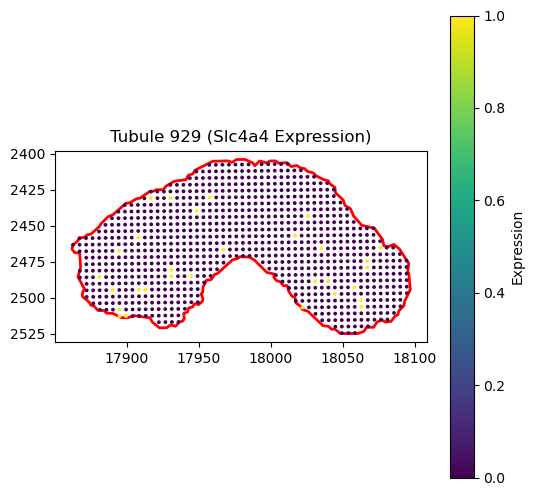

In [103]:
#VISUALIZE GENE EXPRESSION:
expr_all=subset[:, "Slc4a4"].X.toarray()


fig, ax = plt.subplots(figsize=(6,6))

# plotting the polygon (from the geojson file)
gdf[gdf["id"] == "929"].plot(ax=ax, color="none", edgecolor="red", linewidth=2)

# plot the Visium HD bins scatter 
sc = ax.scatter(
    subset.obs["pxl_col_in_fullres"].values,
    subset.obs["pxl_row_in_fullres"].values,
    c=expr_all,
    s=3,
    alpha=1
)

# attach colorbar to SAME figure
fig.colorbar(sc, ax=ax, label="Expression")

ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_title("Tubule 929 (Slc4a4 Expression)")